## Import Packages and Libraries

In [2]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os

## Data Cleaning/Preparation

+ Data cleaning: This involves identifying and correcting errors or inconsistencies in the data, such as missing or duplicate values, incorrect data types, and outliers.

+ Data transformation: This involves transforming the data into a format that is suitable for analysis. This may involve converting data types, standardizing units of measurement, and normalizing or scaling the data.

+ Data integration: This involves combining data from multiple sources into a single dataset. This may involve merging data based on a common key or creating new variables based on existing ones.

+ Feature engineering: This involves creating new variables or features based on the existing data to improve the performance of machine learning algorithms. This may involve creating new variables by combining existing ones or transforming variables to improve their predictive power.

## Graph the BN Model
Graph the Bayesian Network Model using Daft Package

## Prepare the Model in pgmpy
This includes:

+ plugging in CPDs of parent nodes
+ estimating CPDs of the rest of the nodes
+ calculating the likelihood of certain nodes, dependent and independent

In [3]:
#importing data
covid = pd.read_excel("symptomatic_dataset.xlsx")
covid.head(2)

,ID,Completion_Date,Age,Gender,Banana,Caramel,Mint,Orange,Pineapple,Vanilla,...,6__Alzheimer,7__Cold,8__Cough,9__Fever,10__Muscular_pain,11__Breathing_difficulty,12__Other_COMMENTS,13__Days_with_symptoms,Smoker,COVI19_PCR
0,1,2020-06-01,30,Female,0,0,1,0,1,1,...,0,1,0,0,0,0,anosmia,3,0,1
1,2,2020-06-01,31,Female,0,1,1,1,0,1,...,0,0,1,0,1,0,NaN,2,0,1


In [4]:
covid.columns

Index(['ID', 'Completion_Date', 'Age', 'Gender', 'Banana', 'Caramel', 'Mint',
       'Orange', 'Pineapple', 'Vanilla', '1__Rinitis_or_Sinusitis',
       '2__Respiratory_allergies', '3__Hypertension', '4__Diabetes',
       '5__Parkinson', '6__Alzheimer', '7__Cold', '8__Cough', '9__Fever',
       '10__Muscular_pain', '11__Breathing_difficulty', '12__Other_COMMENTS',
       '13__Days_with_symptoms', 'Smoker', 'COVI19_PCR'],
      dtype='object')

In [6]:
#covid.isna().sum()

In [7]:
#Create a mask based on the condition
mask = (covid['Banana'] + covid['Caramel'] + covid['Mint'] + covid['Orange'] + covid['Pineapple'] + covid['Vanilla']) > 3

#Assign the values 1 or 0 to the new column based on the mask
covid['Anosmia'] = mask.astype(int)

In [8]:
#drop columns that are not predictors
dropthis = ["ID", "Completion_Date", #"12__Other_COMMENTS",
            "Banana", "Caramel", "Mint", "Orange", "Pineapple", "Vanilla"]
covid_symp = covid.drop(dropthis, axis=1)

### extracting the comments

In [9]:
# Create a DataFrame with binary encoding for the presence of each value
binary_comments = covid_symp['12__Other_COMMENTS'].str.get_dummies(sep=',')

In [10]:
binary_comments.head(2)

,chest pain,ageusia,allergy,angina,anosmia,augesia,chest pain,depression,diarrhea,dizziness,...,lupus,nausea,nauseas,neumonia,odynophagia,pharyngeal itching,rhinorrhea,sore throat,stomach pain,vomiting
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
#deleting spaces before column names
binary_comments.columns = [col.lstrip() for col in binary_comments.columns]
#checking stats
#binary_comments.sum().sort_values(ascending=False)

In [13]:
binary_comments.columns

Index(['chest pain', 'ageusia', 'allergy', 'angina', 'anosmia', 'augesia',
       'chest pain', 'depression', 'diarrhea', 'dizziness', 'dyspnea',
       'ear pain', 'fatigue', 'fever', 'headache', 'indigestion',
       'lack of appetite', 'nausea', 'odynophagia', 'otalgia', 'rhinorrea',
       'shivers', 'sore throat', 'stomach pain', 'sweating', 'vomiting nausea',
       'ageusia', 'anosmia', 'asma', 'bronchitis', 'chest pain',
       'clogged nose', 'cough', 'depression', 'dermomiositis', 'diarrhea',
       'diarrhea anosmia', 'dizziness', 'dysphagia', 'dyspnea', 'fatigue',
       'fever', 'fibromyalgia', 'headache', 'headache Y diarrhea', 'headache.',
       'headaches', 'hiposmia', 'hipotiridismo', 'hypothyroidism',
       'indigestion', 'lack of appetite', 'lupus', 'nausea', 'nauseas',
       'neumonia', 'odynophagia', 'pharyngeal itching', 'rhinorrhea',
       'sore throat', 'stomach pain', 'vomiting'],
      dtype='object')

In [14]:
sums = binary_comments.sum()
#print(sums)
sorted_cols = sums.sort_values(ascending=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)

sorted_cols

headache               112
anosmia                 46
ageusia                 23
odynophagia             19
headache                17
diarrhea                13
anosmia                 11
asma                    11
odynophagia             10
hypothyroidism           8
diarrhea                 7
sore throat              7
chest pain               6
headaches                5
sore throat              5
fatigue                  4
ageusia                  3
stomach pain             3
clogged nose             3
fatigue                  3
augesia                  3
stomach pain             3
dizziness                2
fever                    2
headache.                2
lack of appetite         2
shivers                  2
lupus                    1
nausea                   1
nauseas                  1
neumonia                 1
hipotiridismo            1
pharyngeal itching       1
rhinorrhea               1
headache Y diarrhea      1
hiposmia                 1
fibromyalgia             1
i

In [32]:
binary_comments
#unique_cols = ~df.columns.duplicated()
#df = df.loc[:, unique_cols]


,chest pain,ageusia,allergy,angina,anosmia,augesia,chest pain,depression,diarrhea,dizziness,dyspnea,ear pain,fatigue,fever,headache,indigestion,lack of appetite,nausea,odynophagia,otalgia,rhinorrea,shivers,sore throat,stomach pain,sweating,vomiting nausea,ageusia,anosmia,asma,bronchitis,chest pain,clogged nose,cough,depression,dermomiositis,diarrhea,diarrhea anosmia,dizziness,dysphagia,dyspnea,fatigue,fever,fibromyalgia,headache,headache Y diarrhea,headache.,headaches,hiposmia,hipotiridismo,hypothyroidism,indigestion,lack of appetite,lupus,nausea,nauseas,neumonia,odynophagia,pharyngeal itching,rhinorrhea,sore throat,stomach pain,vomiting
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [20]:
sums = binary_comments[['headache','headache Y diarrhea']].sum(axis=1)

In [26]:
sums.sort_values(ascending=False)

925    1
660    1
200    1
745    1
210    1
214    1
733    1
732    1
728    1
226    1
227    1
231    1
718    1
712    1
491    1
708    1
707    1
700    1
699    1
265    1
267    1
688    1
684    1
274    1
682    1
282    1
670    1
751    1
752    1
194    1
149    1
813    1
811    1
808    1
807    1
805    1
133    1
803    1
801    1
799    1
795    1
148    1
786    1
758    1
782    1
159    1
160    1
162    1
163    1
165    1
778    1
167    1
170    1
773    1
770    1
295    1
659    1
116    1
653    1
404    1
405    1
563    1
559    1
556    1
552    1
423    1
427    1
542    1
433    1
441    1
523    1
454    1
520    1
458    1
459    1
515    1
513    1
509    1
471    1
507    1
503    1
502    1
482    1
485    1
403    1
401    1
568    1
598    1
652    1
650    1
646    1
317    1
318    1
333    1
628    1
627    1
610    1
604    1
601    1
595    1
570    1
594    1
592    1
591    1
590    1
374    1
586    1
379    1
389    1
391    1
572    1
3

In [28]:
binary_comments.filter(like='headache').columns.to_list()

['headache', 'headache', 'headache Y diarrhea', 'headache.', 'headaches']

In [29]:
filtered_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'headache' in col_name]

print(filtered_cols)

[14, 43, 44, 45, 46]


In [30]:
sums = binary_comments.iloc[:, filtered_cols].sum(axis=0)
sums

headache                17
headache               112
headache Y diarrhea      1
headache.                2
headaches                5
dtype: int64

In [31]:
binary_comments.filter(like='pain').columns.to_list()

['chest pain',
 'chest pain',
 'ear pain',
 'stomach pain',
 'chest pain',
 'stomach pain']

In [7]:
#Age ranges
age_groups = {
    range(0, 13): '0-12',
    range(13, 25): '13-24',
    range(25, 45): '25-44',
    range(45, 66): '45-65',
    range(66, 120): '66+'
}

# encode the age column
covid_symp['Age_group'] = covid_symp['Age'].map(lambda Age: next((a for b, a in age_groups.items() if Age in b), None))

In [8]:
covid_symp = covid_symp.rename(columns={'1__Rinitis_or_Sinusitis': 'RinitisSinusitis',
                        '2__Respiratory_allergies': 'RespiratoryAllegies',
                        '3__Hypertension': 'Hypertension',
                        '4__Diabetes': 'Diabetes',
                        '5__Parkinson': 'Parkinson',
                        '6__Alzheimer': 'Alzheimer',
                        '7__Cold': 'Cold',
                        '8__Cough': 'Cough',
                        '9__Fever': 'Fever',
                        '10__Muscular_pain': 'MuscularPain',
                        '11__Breathing_difficulty': 'BreatheDiff',
                        '13__Days_with_symptoms': 'SymptomDays'                       
                       })

In [9]:
#checking stats
covid_symp.describe()

,Age,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Parkinson,Alzheimer,Cold,Cough,Fever,MuscularPain,BreatheDiff,SymptomDays,Smoker,COVI19_PCR,Anosmia
count,926.000000,926.000000,926.000000,926.000000,926.000000,926.0,926.0,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000
mean,37.293737,0.134989,0.139309,0.095032,0.021598,0.0,0.0,0.338013,0.345572,0.168467,0.371490,0.139309,3.098272,0.281857,0.333693,0.830454
std,13.073849,0.341897,0.346456,0.293418,0.145446,0.0,0.0,0.473289,0.475812,0.374482,0.483464,0.346456,1.421099,0.450147,0.471786,0.375437
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000
50%,35.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,1.000000
75%,46.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.000000,1.000000,0.000000,1.000000,0.000000,5.000000,1.000000,1.000000,1.000000
max,84.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000


In [10]:
#drop Age: age group, Parkinson and Alzheimer has no variance
dropthis = ["Age", "Parkinson", "Alzheimer"]
covid_symp = covid_symp.drop(dropthis, axis=1)

In [11]:
pd.Categorical(covid['Gender']).describe()

,counts,freqs
categories,,
Female,445,0.480562
Masculine,481,0.519438


In [12]:
#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target]).columns.tolist()
features

['Gender',
 'RinitisSinusitis',
 'RespiratoryAllegies',
 'Hypertension',
 'Diabetes',
 'Cold',
 'Cough',
 'Fever',
 'MuscularPain',
 'BreatheDiff',
 'SymptomDays',
 'Smoker',
 'Anosmia',
 'Age_group']

In [13]:
covid_symp.head()

,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Cold,Cough,Fever,MuscularPain,BreatheDiff,SymptomDays,Smoker,COVI19_PCR,Anosmia,Age_group
0,Female,0,0,0,0,1,0,0,0,0,3,0,1,0,25-44
1,Female,0,0,0,0,0,1,0,1,0,2,0,1,1,25-44
2,Female,1,0,0,0,1,0,0,1,0,3,0,1,1,25-44
3,Female,0,0,0,0,1,1,1,1,0,2,0,1,0,25-44
4,Masculine,0,0,0,0,1,1,1,0,0,2,0,1,0,25-44


In [14]:
bnmodel = BayesianNetwork([('Hypertension', 'COVI19_PCR'),
                       ('Diabetes', 'COVI19_PCR'),
                       ('Cough', 'COVI19_PCR'), ('Fever', 'COVI19_PCR'), ('MuscularPain', 'COVI19_PCR'),
                       ('BreatheDiff', 'COVI19_PCR'), ('SymptomDays', 'COVI19_PCR'), ('Smoker', 'COVI19_PCR'),
                       ('Anosmia', 'COVI19_PCR'), ('Cold', 'Fever'), ('Cold', 'Cough'),
                       ('Age_group', 'MuscularPain'), ('Gender', 'Smoker'),
                       ('RespiratoryAllegies', 'COVI19_PCR'), ('RinitisSinusitis', 'Anosmia'), 
                        ('Age_group','RespiratoryAllegies')
                          ])

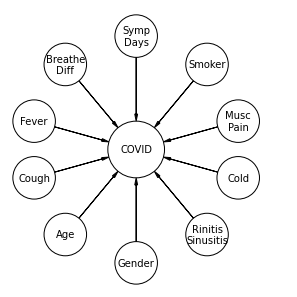

In [15]:
covidpgm = PGM(shape=[5, 5])
covidpgm.add_node(daft.Node("Age", "Age", 1.75, 1.5, scale=1.5))
covidpgm.add_node(daft.Node("COVI19_PCR", r"COVID", 3, 3, scale=2))
covidpgm.add_node(daft.Node("Gender", r"Gender", 3, 1, scale=1.5))
covidpgm.add_node(daft.Node("Rinitis_or_Sinusitis", "Rinitis\nSinusitis", 4.25, 1.5, scale=1.5))
covidpgm.add_node(daft.Node("Cough", r"Cough", 1.2, 2.5, scale=1.5))
covidpgm.add_node(daft.Node("Cold", r"Cold", 4.8, 2.5, scale=1.5))
covidpgm.add_node(daft.Node("Fever", r"Fever", 1.2, 3.5, scale=1.5))
covidpgm.add_node(daft.Node("Muscular_pain", "Musc\nPain", 4.8, 3.5, scale=1.5))
covidpgm.add_node(daft.Node("Breathing_difficulty", "Breathe\nDiff", 1.75, 4.5, scale=1.5))
covidpgm.add_node(daft.Node("Days_with_symptoms", "Symp\nDays", 3, 5, scale=1.5))
covidpgm.add_node(daft.Node("Smoker", r"Smoker", 4.25, 4.5, scale=1.5))


covidpgm.add_edge('Age', 'COVI19_PCR')
covidpgm.add_edge('Gender', 'COVI19_PCR')
covidpgm.add_edge('Rinitis_or_Sinusitis', 'COVI19_PCR')
covidpgm.add_edge('Cold', 'COVI19_PCR')
covidpgm.add_edge('Cough', 'COVI19_PCR')
covidpgm.add_edge('Fever', 'COVI19_PCR')
covidpgm.add_edge('Muscular_pain', 'COVI19_PCR')
covidpgm.add_edge('Breathing_difficulty', 'COVI19_PCR')
covidpgm.add_edge('Days_with_symptoms', 'COVI19_PCR')
covidpgm.add_edge('Smoker', 'COVI19_PCR')

covidpgm.render()
plt.show()

<Axes:>

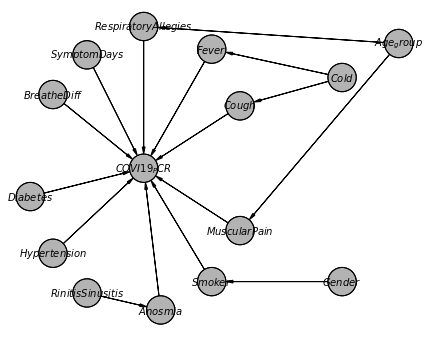

In [16]:
bnmodel.to_daft(node_pos={"Anosmia": (3.3,1),
                          "RinitisSinusitis": (2, 1.3),
                          "Hypertension": (1.4, 2),
                          "Diabetes": (1,3),
                          #"Alzheimer": (1,4),
                          "BreatheDiff": (1.4,4.8),
                          "SymptomDays": (2,5.5),
                          "RespiratoryAllegies": (3,6),
                          "COVI19_PCR": (3,3.5),
                          "Smoker": (4.2,1.5),
                          "MuscularPain": (4.7,2.4),
                          #"Parkinson": (5, 3.5),
                          "Cough": (4.7,4.6),
                          "Fever": (4.2,5.6),
                          "Cold": (6.5,5.1),
                          "Age_group": (7.5,5.7),
                          "Gender": (6.5,1.5)                         
                         }
               ).render()

In [17]:
target = 'COVI19_PCR'
# Define features as all columns except the target variable
features = covid_symp.drop(columns=[target])
# Define target variable
target = covid_symp[target]

In [18]:
covid_symp['Age_group'].unique()

array(['25-44', '45-65', '0-12', '13-24', '66+'], dtype=object)

In [19]:
gender_val = ['Female', 'Masculine']
Gendcpd = TabularCPD(variable='Gender',
                       variable_card=2,
                       values=[[.5021], [.4979]])
Gendcpd.state_names = {'Gender': gender_val}
age_groups = ['0-12', '13-24', '25-44', '45-65', '66+']
Agecpd = TabularCPD(variable='Age_group',
                       variable_card=5,
                       values=[[.17], [.135], [0.282], [0.242], [0.171]])
Agecpd.state_names = {'Age_group': age_groups}
RScpd = TabularCPD(variable='RinitisSinusitis',
                       variable_card=2,
                       values=[[0.16], [.84]])
Hypercpd = TabularCPD(variable='Hypertension',
                       variable_card=2,
                       values=[[0.2557], [.7443]])
Diabcpd = TabularCPD(variable='Diabetes',
                       variable_card=2,
                       values=[[.05], [.95]])
BDcpd = TabularCPD(variable='BreatheDiff',
                       variable_card=2,
                       values=[[.032], [.968]])
#SDayscpd = TabularCPD(variable='SymptomDays',
#                       variable_card=2,
#                       values=[[.579], [.421]])

#ResAlcpd = TabularCPD(variable='RespiratoryAllegies',
#                       variable_card=2,
#                       values=[[0.19,0.19,0.26,0.26,0.26], [0.81,0.81,0.74,0.74,0.74]],
#                       evidence=['Age_group'], evidence_card=[5])
#ResAlcpd.state_names = {'Age_group': age_groups}
Coldcpd = TabularCPD(variable='Cold',
                       variable_card=2,
                       values=[[.137], [.863]])
#MPcpd = TabularCPD(variable='MuscularPain',
#                       variable_card=2,
#                       values=[[0.19,0.19,0.26,0.26,0.26], [0.81,0.81,0.74,0.74,0.74]],
#                       evidence=['Age_group'], evidence_card=[5])
#MPcpd.state_names = {'Age_group': age_groups}

In [21]:
bnmodel.add_cpds(RScpd, Hypercpd, Diabcpd, BDcpd, #SDayscpd,
                #ResAlcpd, 
                 Coldcpd, Agecpd, #MPcpd, 
                Gendcpd
                )

In [22]:
mle = MaximumLikelihoodEstimator(bnmodel, covid_symp)

#RScpd = mle.estimate_cpd('RinitisSinusitis')
#Hypercpd = mle.estimate_cpd('Hypertension')
#Diabcpd = mle.estimate_cpd('Diabetes')
#BDcpd = mle.estimate_cpd('BreatheDiff')
SDayscpd = mle.estimate_cpd('SymptomDays')
ResAlcpd = mle.estimate_cpd('RespiratoryAllegies')
#Coldcpd = mle.estimate_cpd('Cold')
#Agecpd = mle.estimate_cpd('Age_group')
MPcpd = mle.estimate_cpd('MuscularPain')
#Gendcpd = mle.estimate_cpd('Gender')
Anoscpd = mle.estimate_cpd('Anosmia')
Smokcpd = mle.estimate_cpd('Smoker')
Coughcpd = mle.estimate_cpd('Cough')
Fevercpd = mle.estimate_cpd('Fever')
COVIDcpd = mle.estimate_cpd('COVI19_PCR')

In [23]:
bnmodel.add_cpds(COVIDcpd, Fevercpd, Coughcpd, Smokcpd, Anoscpd
                , SDayscpd#, Gendcpd, Agecpd, Coldcpd
                 , ResAlcpd
                #, BDcpd, Diabcpd, Hypercpd, RScpd
                 , MPcpd
                )

In [24]:
# print the state counts for each node
cpds = bnmodel.get_cpds()
for cpd in cpds:
    print(cpd)

+---------------------+------+
| RinitisSinusitis(0) | 0.16 |
+---------------------+------+
| RinitisSinusitis(1) | 0.84 |
+---------------------+------+
+-----------------+--------+
| Hypertension(0) | 0.2557 |
+-----------------+--------+
| Hypertension(1) | 0.7443 |
+-----------------+--------+
+-------------+------+
| Diabetes(0) | 0.05 |
+-------------+------+
| Diabetes(1) | 0.95 |
+-------------+------+
+----------------+-------+
| BreatheDiff(0) | 0.032 |
+----------------+-------+
| BreatheDiff(1) | 0.968 |
+----------------+-------+
+---------+-------+
| Cold(0) | 0.137 |
+---------+-------+
| Cold(1) | 0.863 |
+---------+-------+
+------------------+-------+
| Age_group(0-12)  | 0.17  |
+------------------+-------+
| Age_group(13-24) | 0.135 |
+------------------+-------+
| Age_group(25-44) | 0.282 |
+------------------+-------+
| Age_group(45-65) | 0.242 |
+------------------+-------+
| Age_group(66+)   | 0.171 |
+------------------+-------+
+-------------------+--------+


In [25]:
infer=VariableElimination(bnmodel)

In [31]:
evidence = {'Smoker': 0, 'Fever': 0, 'Cough':0} #0 is false
print(infer.query(['COVI19_PCR'], evidence=evidence))

+---------------+-------------------+
| COVI19_PCR    |   phi(COVI19_PCR) |
+===============+===================+
| COVI19_PCR(0) |            0.5440 |
+---------------+-------------------+
| COVI19_PCR(1) |            0.4560 |
+---------------+-------------------+


# BN model with groups

In [1]:
bnmodel2 = BayesianNetwork([#symptoms
                            ('Anosmia', 'COVI19_PCR'),
                            ('BreatheDiff', 'COVI19_PCR'),
                            ('Cough', 'COVI19_PCR'),
                            ('Cold', 'COVI19_PCR'),
                            ('Fever', 'COVI19_PCR'),
                            ('MuscularPain', 'COVI19_PCR'),
                            ('BreatheDiff', 'COVI19_PCR'),
    
                            #underlying conditions
                            ('Hypertension', 'COVI19_PCR'),
                            ('Diabetes', 'COVI19_PCR'),
                            ('RespiratoryAllegies', 'COVI19_PCR'),
                            ('RinitisSinusitis', 'Anosmia'),
                            ('RespiratoryAllegies', 'COVI19_PCR'),
                            ('Smoker', 'COVI19_PCR'),

                            #backgrounds
                            ('Gender', 'Smoker'),
                            ('Age_group', 'COVI19_PCR'),
                            ('SymptomDays', 'COVI19_PCR')
                            
                          ])

NameError: name 'BayesianNetwork' is not defined

<Axes:>

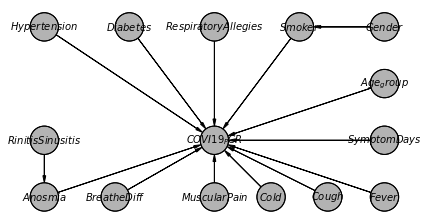

In [58]:
bnmodel2.to_daft(node_pos={
                          #symptoms
                          "Anosmia": (0,1),
                          "BreatheDiff": (1.25,1),
                          "MuscularPain": (3,1),
                          "Cold": (4,1),
                          "Cough": (5,1),
                          "Fever": (6,1),

                          #underlying conditions
                          "RinitisSinusitis": (0,2), 
                          "Hypertension": (0,4),
                          "Diabetes": (1.5,4),
                          "RespiratoryAllegies": (3,4),
                          "Smoker": (,4),

                          #backgrounds
                          "Gender": (6,4),
                          "Age_group": (6,3),
                          "SymptomDays": (6,2),
                          "COVI19_PCR": (3,2)
                         }
               ).render()

Data splitting: This involves splitting the data into training, validation, and testing sets to evaluate the performance of machine learning models.

Data sampling: This involves selecting a representative subset of the data to reduce computation time and improve model performance.

In [11]:
# Initialize a 10-fold stratified sampling
skf = StratifiedKFold(n_splits=10)

In [12]:
# Define lists for storing the training and testing set
X_train_list = []
X_test_list = []
y_train_list = []
y_test_list = []

In [13]:
# Split the data into training and testing set using 10-fold stratified sampling
for train_index, test_index in skf.split(covid_symp[features], covid_symp[target]):
    X_train, X_test = covid_symp[features].iloc[train_index], covid_symp[features].iloc[test_index]
    y_train, y_test = covid_symp[target].iloc[train_index], covid_symp[target].iloc[test_index]
    X_train_list.append(X_train)
    X_test_list.append(X_test)
    y_train_list.append(y_train)
    y_test_list.append(y_test)

In [26]:

covid_pe = ParameterEstimator(bnmodel, covid)
#print("\n", covid_pe.state_counts('Age'))  # unconditional
#print("\n", covid_pe.state_counts('COVID19_PCR'))  # conditional on fruit and size

In [43]:
# Calibrate all CPDs of `model` using MLE:
bnmodel.fit(covid, estimator=MaximumLikelihoodEstimator)

In [44]:
est = BayesianEstimator(bnmodel, covid)

print(est.estimate_cpd('COVI19_PCR', prior_type='BDeu', equivalent_sample_size=10))

+--------------------------+-----+-----------------------------+
| 10__Muscular_pain        | ... | 10__Muscular_pain(1)        |
+--------------------------+-----+-----------------------------+
| 11__Breathing_difficulty | ... | 11__Breathing_difficulty(1) |
+--------------------------+-----+-----------------------------+
| 13__Days_with_symptoms   | ... | 13__Days_with_symptoms(5)   |
+--------------------------+-----+-----------------------------+
| 1__Rinitis_or_Sinusitis  | ... | 1__Rinitis_or_Sinusitis(1)  |
+--------------------------+-----+-----------------------------+
| 7__Cold                  | ... | 7__Cold(1)                  |
+--------------------------+-----+-----------------------------+
| 8__Cough                 | ... | 8__Cough(1)                 |
+--------------------------+-----+-----------------------------+
| 9__Fever                 | ... | 9__Fever(1)                 |
+--------------------------+-----+-----------------------------+
| Age                    

In [46]:
# generate data
bnmodel.fit(covid, estimator=BayesianEstimator, prior_type="BDeu") # default equivalent_sample_size=5
for cpd in bnmodel.get_cpds():
    print(cpd)

+---------+-------------+
| Age(0)  | 0.0224241   |
+---------+-------------+
| Age(9)  | 0.000283849 |
+---------+-------------+
| Age(10) | 0.000283849 |
+---------+-------------+
| Age(13) | 0.000283849 |
+---------+-------------+
| Age(14) | 0.00397389  |
+---------+-------------+
| Age(15) | 0.00397389  |
+---------+-------------+
| Age(16) | 0.000283849 |
+---------+-------------+
| Age(18) | 0.00766392  |
+---------+-------------+
| Age(19) | 0.000283849 |
+---------+-------------+
| Age(20) | 0.015044    |
+---------+-------------+
| Age(21) | 0.00397389  |
+---------+-------------+
| Age(22) | 0.018734    |
+---------+-------------+
| Age(23) | 0.011354    |
+---------+-------------+
| Age(24) | 0.0261141   |
+---------+-------------+
| Age(25) | 0.0261141   |
+---------+-------------+
| Age(26) | 0.0224241   |
+---------+-------------+
| Age(27) | 0.0371842   |
+---------+-------------+
| Age(28) | 0.0408743   |
+---------+-------------+
| Age(29) | 0.0556344   |
+---------+-

In [61]:
evidence = {'Smoker': 0, 'Age': 50, '9__Fever': 1}
print(infer.query(['COVI19_PCR'], evidence=evidence))

+---------------+-------------------+
| COVI19_PCR    |   phi(COVI19_PCR) |
+===============+===================+
| COVI19_PCR(0) |            0.4996 |
+---------------+-------------------+
| COVI19_PCR(1) |            0.5004 |
+---------------+-------------------+


In [57]:
# define the evidence dictionary
evidence = {'Smoker': 1, 'Age_': 24}

# find the conditional probability distribution of Y given the evidence
cpd_y_given = bnmodel.predict(variables=['10__Muscular_pain'], evidence=evidence)

# print the resulting conditional probability distribution
print(cpd_y_given)

TypeError: predict() got an unexpected keyword argument 'variables'

In [34]:
# get the system's virtual memory
vm = psutil.virtual_memory()

# print the total, available, and used memory in the system
print(f"Total memory: {vm.total/(1024*1024*1024):.2f} GB")
print(f"Available memory: {vm.available/(1024*1024*1024):.2f} GB")
print(f"Used memory: {vm.used/(1024*1024*1024):.2f} GB")

Total memory: 15.70 GB
Available memory: 6.43 GB
Used memory: 9.28 GB
